
- The DB contains 23 records (from 100 to 124) chosen at random from inpatients and 25 records (200-234) of rare but clinically important phenomena. These 48 records are ~ 30 minutes long.
- First group provides a sample of waves and artifacts that can be encountered by an arrhythmia detector while second one include complex ventricular, junctional and supraventricular arrhythmias and conduction abnormalities. 
- Record 201 and 202 comes from the same male subject.
- Analog signals were digitized at 360Hz. 


In [16]:
import wfdb  
import os 
from pathlib import Path 

PROJECT_ROOT = f"data/raw/mit-bih-arrhythmia-database-1.0.0/"
PROJECT_ROOT = Path(PROJECT_ROOT)

In [17]:
import numpy as np 
from scipy.signal import firwin, iirnotch, butter, filtfilt

FS = 360  # MIT-BIH sampling frequency
PACED_RECORDS = {'102', '104', '107', '217'}
AAMI_MAP = {"N":"N", "L":"N", "R":"N", "e":"N", "j":"N", 
                            "A":"S", "a":"S", "S":"S", "J":"S", 
                            "V":"V", "E":"V", 
                            #"F":"F", #Removed F and Q as there are not relevant to arrhythmia detection  
                            # "/":'Q', "f": "Q", "Q":"Q",
                            }


def preprocess_ecg(signal: np.ndarray) -> np.ndarray:
    """
    4-step FIR Kaiser pipeline from Sravan Kumar et al. (2015):
    1. HPF 0.5 Hz  -> remove baseline wander
    2. BSF 59.5-60.5 Hz -> remove power line interference
    3. LPF 100 Hz  -> remove EMG noise
    4. Moving average -> smooth
    """
    hp = firwin(57, cutoff=0.5, window=('kaiser', 8.6), pass_zero=False, fs=FS)
    signal = filtfilt(hp, 1.0, signal)

    bs = firwin(57, cutoff=[59.5, 60.5], window=('kaiser', 8.6), pass_zero=True, fs=FS)
    signal = filtfilt(bs, 1.0, signal)

    lp = firwin(57, cutoff=100.0, window=('kaiser', 8.6), pass_zero=True, fs=FS)
    signal = filtfilt(lp, 1.0, signal)

    kernel = np.ones(5) / 5
    signal = np.convolve(signal, kernel, mode='same')

    return signal




def _load_mit_bih(window_len = 128, extension="atr", preprocess = False):
    files = [f for f  in PROJECT_ROOT.iterdir() if f.is_file() and f.suffix == ".hea"]
    X_all = {}
    y_all = {}
    SYM_all = {}
    RR_all = {}

    half_window_len = window_len // 2 

    beat_symbols = list(AAMI_MAP.keys())

    for f in files:
        if f.stem in PACED_RECORDS:
            continue

        record = wfdb.rdrecord(record_name=f.with_suffix(''))
        annotation = wfdb.rdann(record_name=str(f.with_suffix('')), extension=extension)
        
        clean_signal = preprocess_ecg(record.p_signal[:, 0]) if preprocess else record.p_signal[:, 0]

        in_flutter = False 
        in_flutter_indices = set()
        for i, sym in enumerate(annotation.symbol):
            if sym == '[':
                in_flutter = True 
            elif sym == ']':
                in_flutter = False 
            elif in_flutter:
                in_flutter_indices.add(i)

        valid_beats = [] 
        for i , sample_idx in enumerate(annotation.sample):
            if annotation.symbol[i] not in beat_symbols:
                continue 
            if i in in_flutter_indices:
                continue 
            if  sample_idx-half_window_len < 0 or sample_idx+half_window_len > record.sig_len:
                continue  
            
            valid_beats.append((i, sample_idx, AAMI_MAP[annotation.symbol[i]]))
       
        x, y, sym, rr = [], [], [], []
        
        for pos, (i, sample_idx, label) in enumerate(valid_beats):
            pre_rr  = (valid_beats[pos][1] - valid_beats[pos-1][1]) / FS if pos > 0 else 0.0
            post_rr = (valid_beats[pos+1][1] - valid_beats[pos][1]) / FS if pos < len(valid_beats)-1 else 0.0
            local_mean_rr = np.mean(np.diff([b[1] for b in valid_beats[max(0, pos-80):pos+1]])) / FS if pos > 0 else pre_rr
            global_mean_rr = np.mean(np.diff([b[1] for b in valid_beats[max(0, pos-400):pos+1]])) / FS if pos > 0 else pre_rr

            pre_rr_local  = pre_rr / local_mean_rr if local_mean_rr > 0 else 1.0
            post_rr_local = post_rr / local_mean_rr if local_mean_rr > 0 else 1.0
            pre_rr_global  = pre_rr / global_mean_rr if global_mean_rr > 0 else 1.0
            post_rr_global = post_rr / global_mean_rr if global_mean_rr > 0 else 1.0
            rr.append([pre_rr_local, post_rr_local, pre_rr_global, post_rr_global])
            
            seg = clean_signal[sample_idx-half_window_len:sample_idx+half_window_len]

            x.append(seg)
            y.append(label)
            sym.append(annotation.symbol[i])


        X_all[f.stem] = np.expand_dims(np.stack(x), axis=1).astype("float32")
        # X_all[f.stem] = np.permute_dims(np.stack(x), axes=(0,2,1)).astype("float32")
        y_all[f.stem] = np.array(y)
        SYM_all[f.stem] = np.array(sym)
        RR_all[f.stem] = np.array(rr, dtype="float32")
    

    return X_all, y_all, SYM_all, RR_all

In [18]:
from baselines.data.utils import aami_split

def load_mit_bih(nb_patients=48, test_size=0.2, val_size=0.1, seed=42, mode="design"):
    assert mode in ("design", "final"), f"mode must be 'design' or 'final', got {repr(mode)}"
    PROJECT_ROOT = f"data/raw/mit-bih-arrhythmia-database-1.0.0/"
    #preprocess 

    X_all, y_all, SYM_all, RR_all = _load_mit_bih()
    
    classes_n = np.unique(np.concatenate(list(y_all.values()), axis=0))
    print(f"labels {classes_n}")
    label_encoder = {val: idx for idx, val in enumerate(classes_n)}
    y_all_encoded = {}
    for patient, patient_labels in y_all.items():
        y_all_encoded[patient] = np.array([label_encoder[val] for val in patient_labels])

    splits = aami_split(mode=mode, val_size=val_size)

    X_train = []
    X_val = []
    X_test = []
    
    RR_train = []
    RR_val = []
    RR_test = []

    y_train = []
    y_val = []
    y_test = []


    sym_train = []
    for client_id, patient_id in enumerate(splits.train):
        X_train.append(X_all[patient_id])
        y_train.append(y_all_encoded[patient_id])
        RR_train.append(RR_all[patient_id])
        sym_train.append(SYM_all[patient_id])

    
    X_train = np.concatenate(X_train)
    y_train = np.concatenate(y_train)
    RR_train = np.concatenate(RR_train)
    sym_train = np.concatenate(sym_train)
    
    beat_symbols = list(AAMI_MAP.keys())
    matched_filters = np.stack([X_train[sym_train == s].mean(axis=0) for s in beat_symbols if (sym_train == s).any()])


    x_mean = np.mean(X_train, axis=0)
    x_std = np.std(X_train, axis=0)

    X_test = np.concatenate([X_all[i] for i in splits.test])
    y_test = np.concatenate([y_all_encoded[i] for i in splits.test])
    RR_test = np.concatenate([RR_all[i] for i in splits.test])


    if splits.val is not None:
        X_val = np.concatenate([X_all[i] for i in splits.val])
        y_val = np.concatenate([y_all_encoded[i] for i in splits.val])
        RR_val = np.concatenate([RR_all[i] for i in splits.val])

    
    return {"train": ((X_train - x_mean) / (x_std + 1e-8), RR_train,y_train), 
            "test": ((X_test - x_mean) / (x_std + 1e-8), RR_test, y_test),
            "val": ((X_val - x_mean) / (x_std + 1e-8), RR_val, y_val) if mode == "design" else None,
            "matched_filters": matched_filters}
    

In [ ]:
dataset =  load_mit_bih()
#TODO labels 

labels ['N' 'S' 'V']


In [20]:
from torch.utils.data import DataLoader, Dataset
import torch 

class MitbihDataset(Dataset):
    def __init__(self, X, RR, y):
        super().__init__()
        self.x = torch.as_tensor(X, dtype=torch.float32)
        self.rr = torch.as_tensor(RR, dtype=torch.float32)
        self.y = torch.as_tensor(y, dtype=torch.long)
        self.deriv_x = torch.diff(self.x, dim=-1, prepend=self.x[..., :1])

    def __getitem__(self, index):
        return self.deriv_x[index], self.rr[index], self.y[index]

    def __len__(self):
        return len(self.y)


In [21]:
# https://dergipark.org.tr/en/download/article-file/4421862
import torch.nn as nn 
import torch 

class tinyCNN(nn.Module):
    def __init__(self, matched_filters, trainable_conv = True):
        super().__init__()
        mf = torch.as_tensor(matched_filters, dtype=torch.float32) 
        if not trainable_conv:
            self.register_buffer("mf", mf)
        else:
            self.mf = nn.Parameter(mf.clone())
        
        n_filters = mf.shape[0]

        self.post_convolution = nn.Sequential(
            nn.BatchNorm1d(n_filters),
            nn.Tanh(),
            nn.AdaptiveAvgPool1d(1),
        )

        self.rr_path = nn.Sequential(
            nn.Linear(4, 32),
            nn.ReLU(),
            nn.Linear(32,16),
            nn.ReLU(),
            nn.Linear(16, 8),
        )

        self.merger = nn.Sequential(
            nn.Linear(n_filters + 8, 3)
        )

        self._init_weights()

    def _init_weights(self):
        for layer in self.modules():
            if isinstance(layer, nn.Linear):
                nn.init.kaiming_normal_(layer.weight)
                nn.init.zeros_(layer.bias)
            elif isinstance(layer, nn.BatchNorm1d):
                nn.init.ones_(layer.weight)
                nn.init.zeros_(layer.bias)

    def forward(self, X, rr):
        conv_out = nn.functional.conv1d(input=X, weight=self.mf)
        conv_out = self.post_convolution(conv_out)
        rr_path_out = self.rr_path(rr)
        return self.merger(torch.cat([conv_out.squeeze(), rr_path_out], dim=1))

class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.convolutions = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Dropout(0.2),

            nn.Conv1d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Dropout(0.2),

            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Dropout(0.2),
        )

        self.attention = nn.MultiheadAttention(embed_dim=64, num_heads=4, 
                                               dropout=0.2, batch_first=True)
        self.norm = nn.LayerNorm(64)

        self.linears = nn.Sequential(
            nn.Linear(64 * 8 + 4, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 3),
        )

        self._init_weights()
    
    def _init_weights(self):
        for layer in self.modules():
            if isinstance(layer, (nn.Conv1d, nn.Linear)):
                nn.init.kaiming_normal_(layer.weight)
                nn.init.zeros_(layer.bias)
            elif isinstance(layer, nn.BatchNorm1d):
                nn.init.ones_(layer.weight)
                nn.init.zeros_(layer.bias)
    
    
    def forward(self, X, rr):
        out = self.convolutions(X)
        out = out.permute(0, 2, 1)          
        attn_out, _ = self.attention(out, out, out)
        out = self.norm(out + attn_out)     
        out = torch.cat([out.flatten(1), rr], dim=1)
        return self.linears(out)

In [22]:
batch_size = 128 
train_ds = MitbihDataset(*dataset["train"])
train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True)

val_ds = MitbihDataset(*dataset["val"])
val_dl = DataLoader(val_ds, batch_size=batch_size, shuffle=False)


test_ds = MitbihDataset(*dataset["test"])
test_dl = DataLoader(test_ds, batch_size=batch_size, shuffle=False)


In [23]:
from tqdm import tqdm  
import copy 
from baselines.models.evaluate import test_model

def train_model(
    model,
    train_dl,
    optimizer,
    criterion,
    epochs,
    val_dl=None,
    val_period=5,
    tolerated_steps=3,
    device=torch.device("cpu"),):

    cm = None
    best_f1_score = -np.inf
    tolerated_steps_ctr = tolerated_steps
    best_model = copy.deepcopy(model.state_dict())
    for epoch in tqdm(range(epochs)):
        model.train()
        empirical_risk = 0.0
        for *inputs, y in train_dl:
            inputs = [x.to(device) for x in inputs]
            y = y.to(device)
            optimizer.zero_grad()
            pred = model(*inputs)
            loss = criterion(pred, y)
            loss.backward()
            optimizer.step()
            empirical_risk += loss.item()

        empirical_risk /= len(train_dl)
        print(f"Epoch [{epoch + 1}/{epochs}] | Train loss: {empirical_risk:.4f}")
        if val_dl is not None and (epoch + 1) % val_period == 0:
            print(f"{'─' * 40}")
            print(f"  Validation @ epoch {epoch + 1}")
            results = test_model(model, val_dl, criterion, device=device, normal_class=0, log_artifacts=True)
            metrics = {f"val/{k}": v for k, v in results[0].items()}
            cm = results[0]["multiclass/confusion_matrix"]
                
            if results[0]["multiclass/macro_f1"] > best_f1_score:
                best_f1_score = results[0]["multiclass/macro_f1"]
                cm = results[0]["multiclass/confusion_matrix"]
                best_model = copy.deepcopy(model.state_dict())
                tolerated_steps_ctr = tolerated_steps
            else:
                tolerated_steps_ctr -= 1

            print(
                f"  loss: {metrics['val/loss']:.4f}  | multiclass/macro_f1: {metrics['val/multiclass/macro_f1']} | multiclass/balanced_accuracy: {metrics['val/multiclass/balanced_accuracy']} | binary/balanced_accuracy: {metrics['val/binary/balanced_accuracy']} | binary/f1: {metrics['val/binary/f1']} (best f1: {best_f1_score:.4f} patience: {tolerated_steps_ctr}/{tolerated_steps})"
            )
            print(f"{'─' * 40}")

            if tolerated_steps_ctr == 0:
                model.load_state_dict(best_model)
                break

    if val_dl is not None:
        model.load_state_dict(best_model)

    return cm 


  2%|▏         | 1/50 [00:02<01:58,  2.42s/it]

Epoch [1/50] | Train loss: 0.8590


  4%|▍         | 2/50 [00:04<01:53,  2.36s/it]

Epoch [2/50] | Train loss: 0.4608


  6%|▌         | 3/50 [00:07<01:50,  2.35s/it]

...

Epoch [48/50] | Train loss: 0.0584


 98%|█████████▊| 49/50 [01:58<00:02,  2.44s/it]

Epoch [49/50] | Train loss: 0.0550
Epoch [50/50] | Train loss: 0.0519
────────────────────────────────────────
  Validation @ epoch 50


100%|██████████| 50/50 [02:01<00:00,  2.42s/it]

              precision    recall  f1-score   support

           0       1.00      0.93      0.96      3367
           1       0.00      0.33      0.01         3
           2       0.90      0.88      0.89       520

    accuracy                           0.92      3890
   macro avg       0.63      0.72      0.62      3890
weighted avg       0.99      0.92      0.95      3890

  loss: 0.0020  | multiclass/macro_f1: 0.6211381191481817 | multiclass/balanced_accuracy: 0.7157071907071907 | binary/balanced_accuracy: 0.9636359196588642 | binary/f1: 0.8166144200626959 (best f1: 0.6327 patience: 92/100)
────────────────────────────────────────


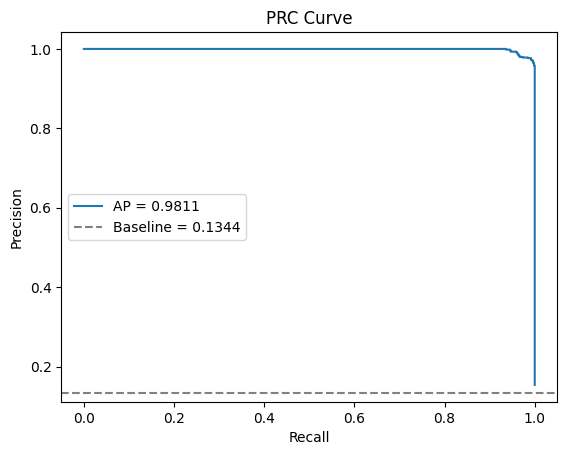

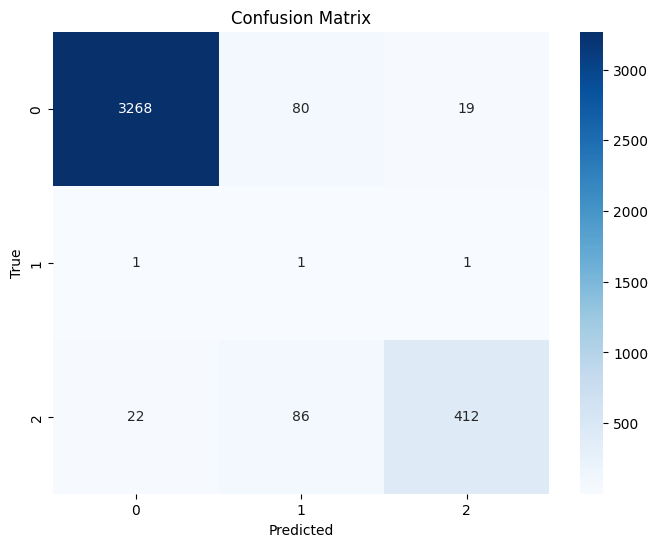

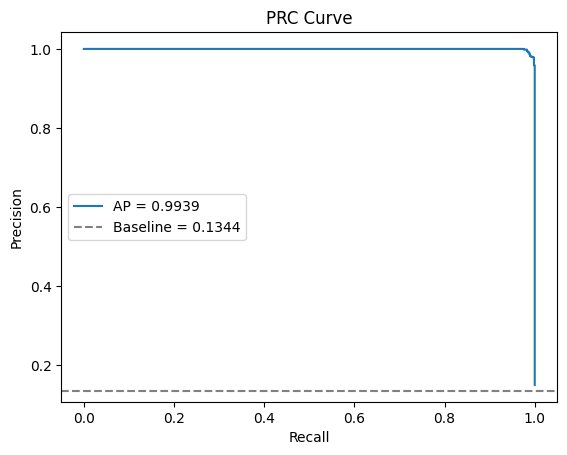

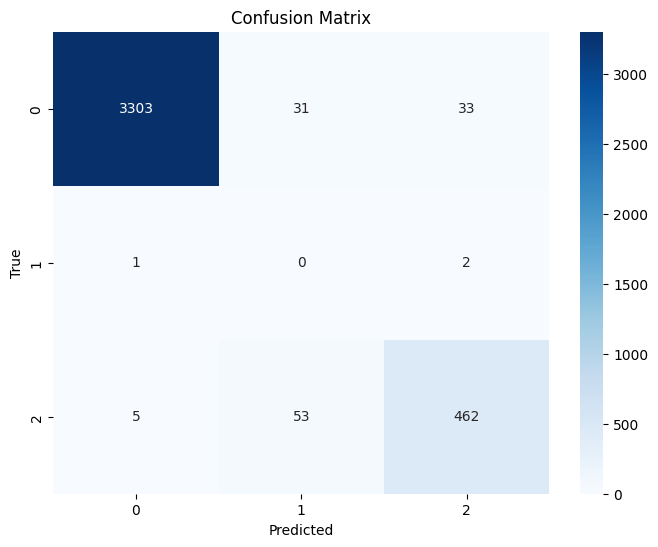

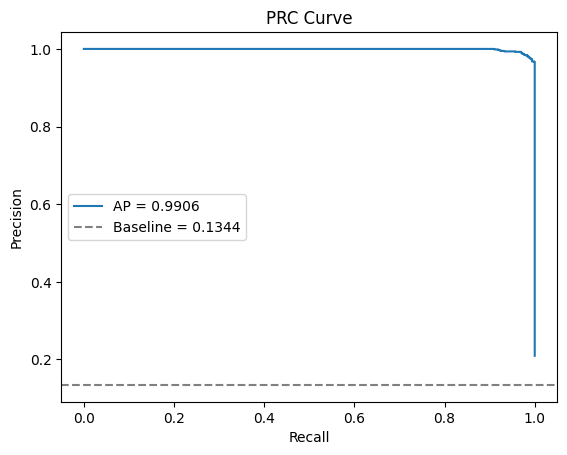

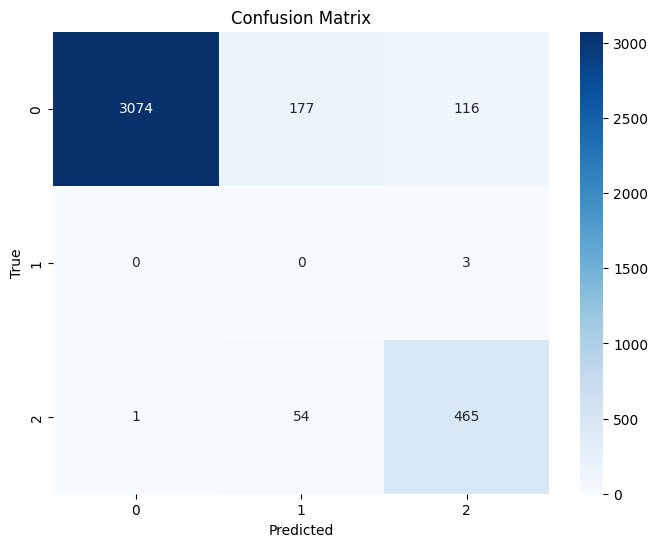

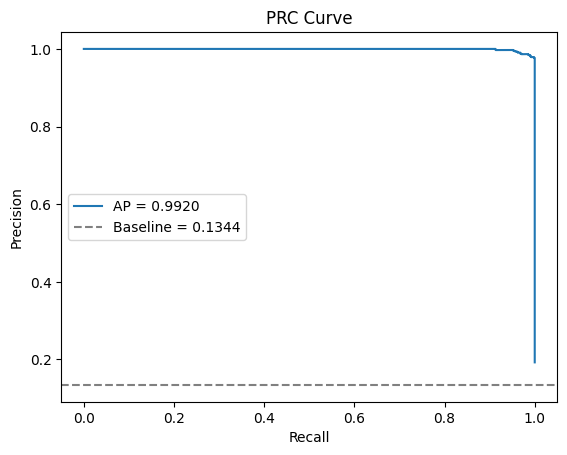

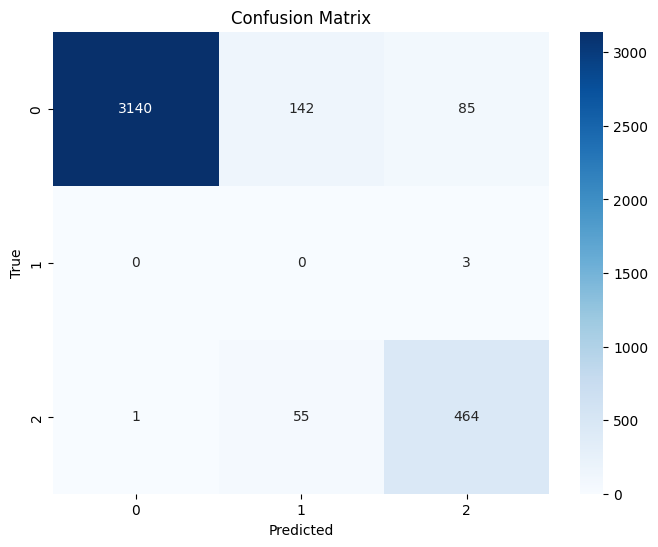

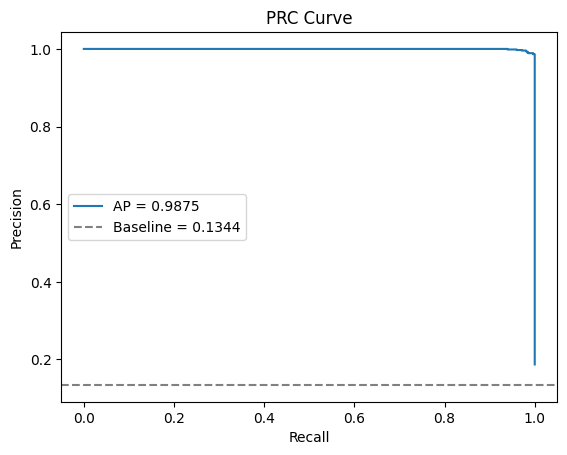

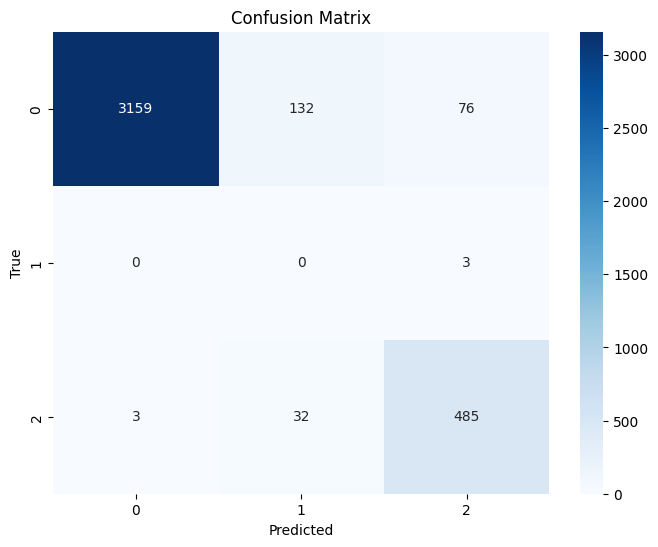

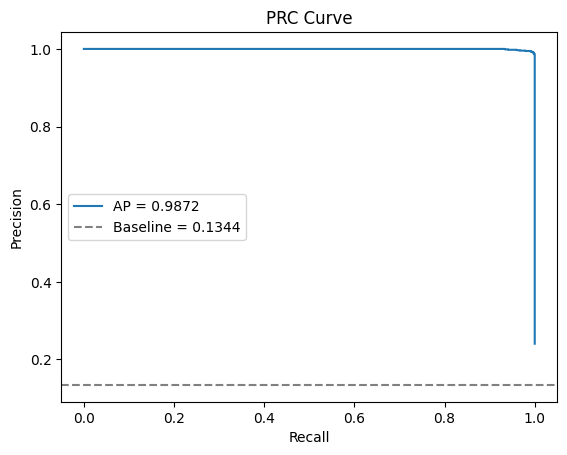

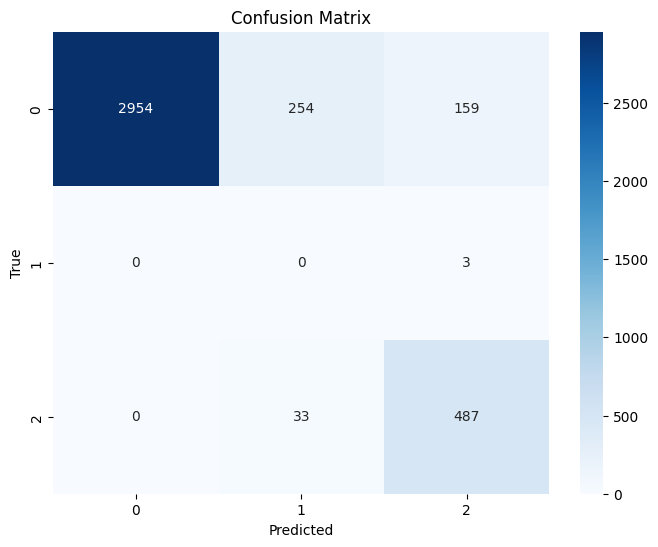

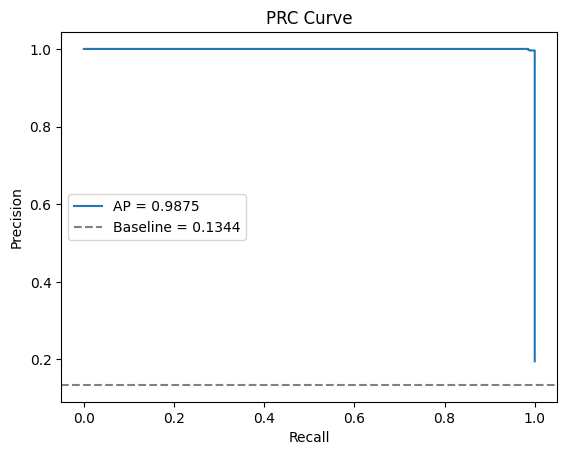

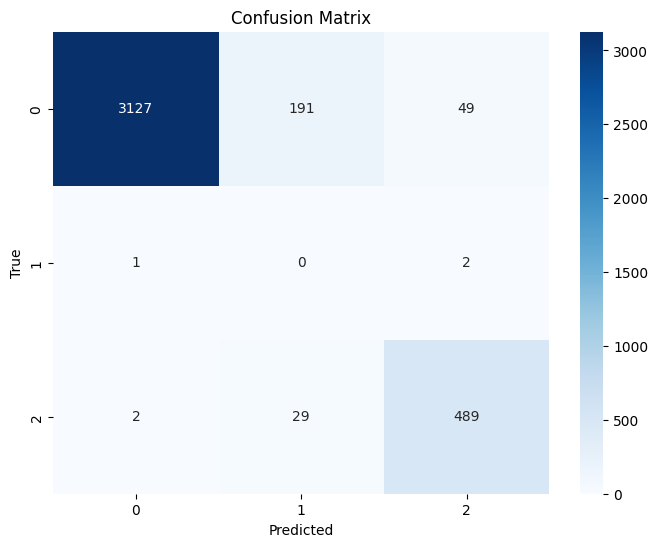

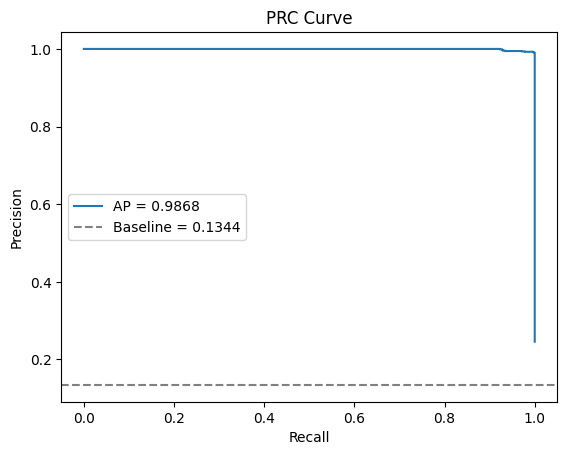

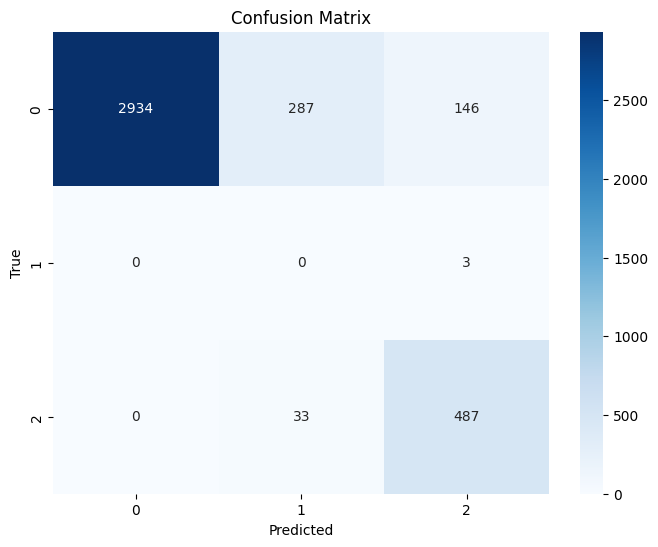

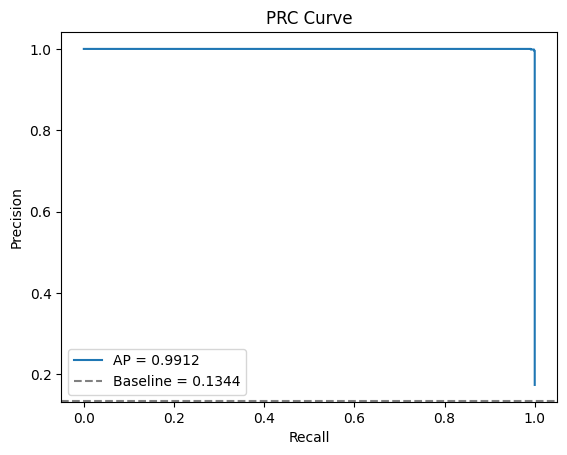

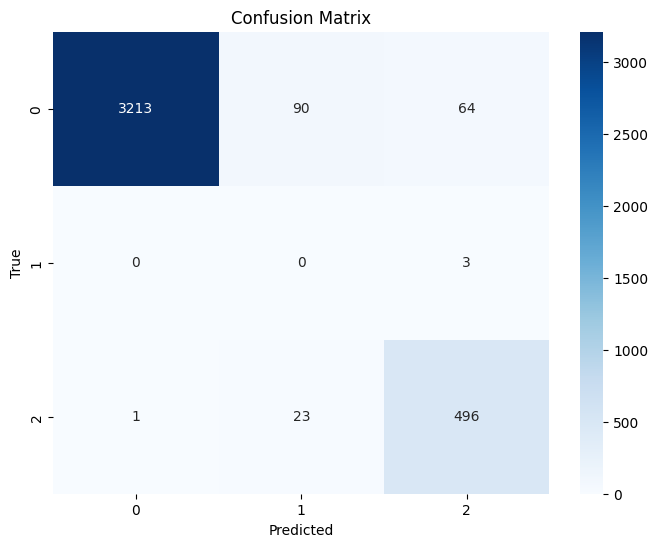

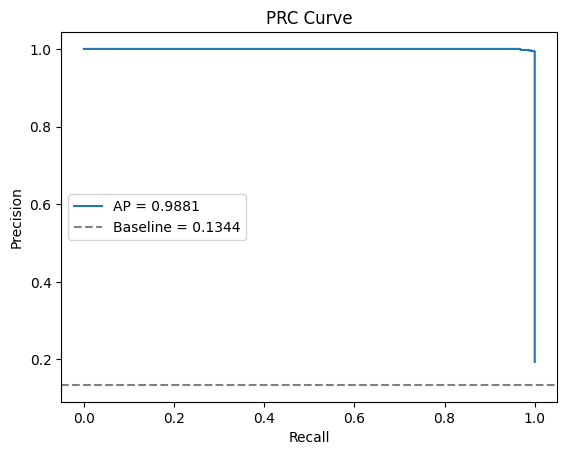

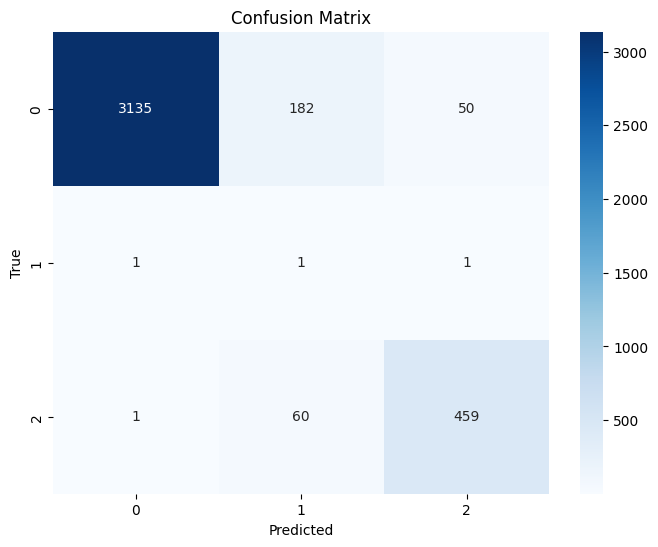

In [24]:
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt 
import seaborn as sns 

DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
epochs = 50
lr = 0.001
model = tinyCNN(matched_filters=dataset["matched_filters"]).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
weights = compute_class_weight("balanced", classes=np.unique(dataset["train"][-1]), y=dataset["train"][-1])

weights = torch.Tensor(weights).to(DEVICE)
criterion = torch.nn.CrossEntropyLoss(weight=weights)

cm = train_model(model, train_dl, optimizer, criterion=criterion, 
            epochs=epochs, val_dl=val_dl, tolerated_steps=100, device=DEVICE)

              precision    recall  f1-score   support

           0       0.99      0.94      0.97     44251
           1       0.36      0.68      0.47      1837
           2       0.76      0.95      0.85      3220

    accuracy                           0.93     49308
   macro avg       0.70      0.85      0.76     49308
weighted avg       0.95      0.93      0.94     49308



[{'loss': 0.0019959662317649025,
  'multiclass/confusion_matrix': array([[41538,  2147,   566],
         [  217,  1241,   379],
         [   62,   102,  3056]]),
  'multiclass/balanced_accuracy': 0.8544389829997575,
  'multiclass/macro_f1': 0.759195080923909,
  'multiclass/classification_report': '              precision    recall  f1-score   support\n\n           0       0.99      0.94      0.97     44251\n           1       0.36      0.68      0.47      1837\n           2       0.76      0.95      0.85      3220\n\n    accuracy                           0.93     49308\n   macro avg       0.70      0.85      0.76     49308\nweighted avg       0.95      0.93      0.94     49308\n',
  'binary/f1': 0.7615556263946446,
  'binary/balanced_accuracy': 0.9417598005145357,
  'binary/ap_score': 0.8769749424601044}]

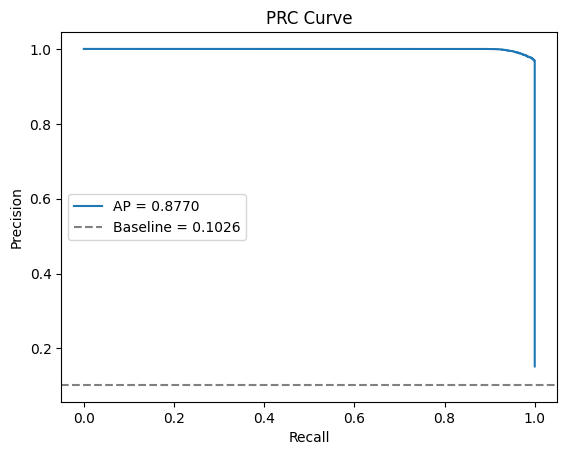

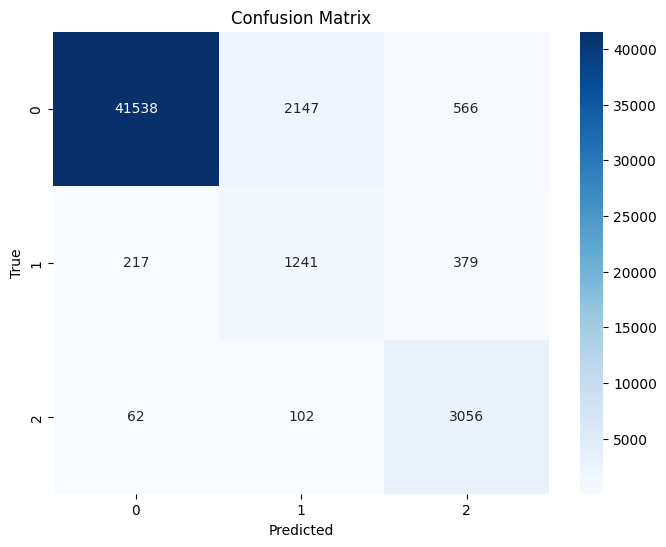

In [25]:
results = test_model(model, test_dl, criterion, device=DEVICE, normal_class=0, log_artifacts=True)
results

In [26]:
results[0]['multiclass/classification_report']

'              precision    recall  f1-score   support\n\n           0       0.99      0.94      0.97     44251\n           1       0.36      0.68      0.47      1837\n           2       0.76      0.95      0.85      3220\n\n    accuracy                           0.93     49308\n   macro avg       0.70      0.85      0.76     49308\nweighted avg       0.95      0.93      0.94     49308\n'

In [27]:
record = wfdb.rdrecord(base_path/"100")
annotation = wfdb.rdann(str(base_path/"100"), extension="atr")

wfdb.plot_wfdb(record=record, annotation=annotation, plot_sym=True, time_units="seconds", figsize=(10,4))

NameError: name 'base_path' is not defined